# Deep Learning Frameworks Primer

This notebook compares TensorFlow and PyTorch tensors, inspects automatic differentiation, and minimizes the same scalar function with pure Python and both frameworks.

## Computation graphs, backpropagation, and frameworks

A computation graph represents a calculation as nodes connected by data dependencies. Tensors and parameters carry values, operation nodes transform them, and directed edges show which results are needed by later operations. For `y = (x - 6)²`, subtraction, squaring, and the final scalar value form a small graph. Eager execution evaluates operations immediately, but a framework can still record the operations needed for differentiation or trace them into a reusable graph.

Backpropagation applies the chain rule from the final scalar loss toward earlier nodes. A forward pass computes values and keeps the information required by local derivative rules. The backward pass combines an incoming gradient with each local derivative, accumulates gradients when paths meet, and produces a gradient for every trainable parameter. An optimizer then uses those gradients to update the parameters. Reverse-mode differentiation is efficient for neural networks because one scalar loss usually depends on many parameters.

A deep learning framework provides tensor storage, shape and broadcasting rules, optimized numerical kernels, device placement, automatic differentiation, reusable layers, parameter tracking, optimizers, data pipelines, serialization, and debugging utilities. A small custom framework would need a tensor type, an operation graph or tape, derivative rules for every supported operation, reverse graph traversal, gradient accumulation, shape handling, parameter and module abstractions, optimizers, numerical checks, and eventually efficient CPU or GPU kernels.

In [1]:
import shutil
import subprocess

import matplotlib.pyplot as plt
import tensorflow as tf
import torch

tf.random.set_seed(42)
torch.manual_seed(42)

gpu_name = "Not detected"
if shutil.which("nvidia-smi"):
    query = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True,
        text=True,
        check=True,
    )
    gpu_name = query.stdout.strip()

print(f"TensorFlow: {tf.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"System GPU: {gpu_name}")
print(f"TensorFlow GPU devices: {tf.config.list_physical_devices('GPU')}")
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
print("Selected device: CPU")

TensorFlow: 2.21.0
PyTorch: 2.13.0+cpu
System GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


TensorFlow GPU devices: []
PyTorch CUDA available: False
Selected device: CPU


## Tensor operations

Both frameworks create typed tensors from Python lists and use NumPy-like element-wise syntax. The comparison uses addition, subtraction, multiplication, and exponentiation on the same float values.

In [2]:
values = [1.0, 2.0, 3.0, 4.0]
tensorflow_tensor = tf.constant(values, dtype=tf.float64)
pytorch_tensor = torch.tensor(values, dtype=torch.float64)

tensorflow_results = {
    "add 2": tensorflow_tensor + 2,
    "subtract 1": tensorflow_tensor - 1,
    "multiply by 3": tensorflow_tensor * 3,
    "square": tensorflow_tensor**2,
}
pytorch_results = {
    "add 2": pytorch_tensor + 2,
    "subtract 1": pytorch_tensor - 1,
    "multiply by 3": pytorch_tensor * 3,
    "square": pytorch_tensor**2,
}

print("TensorFlow tensor:", tensorflow_tensor.numpy().tolist())
print("PyTorch tensor:   ", pytorch_tensor.numpy().tolist())
for operation in tensorflow_results:
    tensorflow_values = tensorflow_results[operation].numpy().tolist()
    pytorch_values = pytorch_results[operation].numpy().tolist()
    print(f"{operation:>14} | TensorFlow {tensorflow_values} | PyTorch {pytorch_values}")
    assert tensorflow_values == pytorch_values

TensorFlow tensor: [1.0, 2.0, 3.0, 4.0]
PyTorch tensor:    [1.0, 2.0, 3.0, 4.0]
         add 2 | TensorFlow [3.0, 4.0, 5.0, 6.0] | PyTorch [3.0, 4.0, 5.0, 6.0]
    subtract 1 | TensorFlow [0.0, 1.0, 2.0, 3.0] | PyTorch [0.0, 1.0, 2.0, 3.0]
 multiply by 3 | TensorFlow [3.0, 6.0, 9.0, 12.0] | PyTorch [3.0, 6.0, 9.0, 12.0]
        square | TensorFlow [1.0, 4.0, 9.0, 16.0] | PyTorch [1.0, 4.0, 9.0, 16.0]


## Automatic differentiation

At `x = 0`, the analytical derivative of `x² - 12x + 36` is `2x - 12 = -12`. TensorFlow records operations inside a gradient tape, while PyTorch records operations when a tensor requires gradients.

In [3]:
tensorflow_x = tf.Variable(0.0, dtype=tf.float64)
with tf.GradientTape() as tape:
    tensorflow_y = tensorflow_x**2 - 12 * tensorflow_x + 36
tensorflow_gradient = tape.gradient(tensorflow_y, tensorflow_x)

pytorch_x = torch.tensor(0.0, dtype=torch.float64, requires_grad=True)
pytorch_y = pytorch_x**2 - 12 * pytorch_x + 36
pytorch_y.backward()

print(f"Analytical gradient: -12.0")
print(f"TensorFlow gradient: {tensorflow_gradient.numpy():.1f}")
print(f"PyTorch gradient: {pytorch_x.grad.item():.1f}")
assert tensorflow_gradient.numpy() == -12.0
assert pytorch_x.grad.item() == -12.0

Analytical gradient: -12.0
TensorFlow gradient: -12.0
PyTorch gradient: -12.0


## Gradient descent from scratch

The objective can be rewritten as `(x - 6)²`, so its unique analytical minimum is `x = 6` with objective value `0`. The pure Python implementation uses only built-in arithmetic and explicitly applies `x ← x - learning_rate × gradient`.

In [4]:
def objective(value):
    return value**2 - 12 * value + 36


def objective_gradient(value):
    return 2 * value - 12


def optimize_with_python(initial_value, learning_rate, steps):
    value = float(initial_value)
    history = [objective(value)]
    for _ in range(steps):
        value -= learning_rate * objective_gradient(value)
        history.append(objective(value))
    return value, history


initial_value = -8.0
learning_rate = 0.1
steps = 80
python_value, python_history = optimize_with_python(initial_value, learning_rate, steps)

print(f"Initial x: {initial_value:.1f}")
print(f"Final x: {python_value:.12f}")
print(f"Final objective: {objective(python_value):.3e}")

Initial x: -8.0
Final x: 5.999999752641
Final objective: 6.395e-14


## TensorFlow optimization

TensorFlow derives the gradient from recorded operations. The update remains visible so the loop mirrors the pure Python implementation.

In [5]:
def optimize_with_tensorflow(initial_value, learning_rate, steps):
    value = tf.Variable(initial_value, dtype=tf.float64)
    history = [float(objective(value).numpy())]
    for _ in range(steps):
        with tf.GradientTape() as tape:
            loss = objective(value)
        gradient = tape.gradient(loss, value)
        value.assign_sub(learning_rate * gradient)
        history.append(float(objective(value).numpy()))
    return float(value.numpy()), history


tensorflow_value, tensorflow_history = optimize_with_tensorflow(
    initial_value, learning_rate, steps
)
print(f"Final x: {tensorflow_value:.12f}")
print(f"Final objective: {objective(tensorflow_value):.3e}")

Final x: 5.999999752641
Final objective: 6.395e-14


## PyTorch optimization

PyTorch stores the gradient on the trainable tensor after `backward()`. SGD applies the update, and `zero_grad()` prevents gradients from accumulating across iterations.

In [6]:
def optimize_with_pytorch(initial_value, learning_rate, steps):
    value = torch.tensor(initial_value, dtype=torch.float64, requires_grad=True)
    optimizer = torch.optim.SGD([value], lr=learning_rate)
    history = [objective(value).item()]
    for _ in range(steps):
        optimizer.zero_grad()
        loss = objective(value)
        loss.backward()
        optimizer.step()
        history.append(objective(value).item())
    return value.item(), history


pytorch_value, pytorch_history = optimize_with_pytorch(
    initial_value, learning_rate, steps
)
print(f"Final x: {pytorch_value:.12f}")
print(f"Final objective: {objective(pytorch_value):.3e}")

Final x: 5.999999752641
Final objective: 6.395e-14


## Convergence comparison

Pure Python | x = 5.999999752641 | objective = 6.395e-14
 TensorFlow | x = 5.999999752641 | objective = 6.395e-14
    PyTorch | x = 5.999999752641 | objective = 6.395e-14


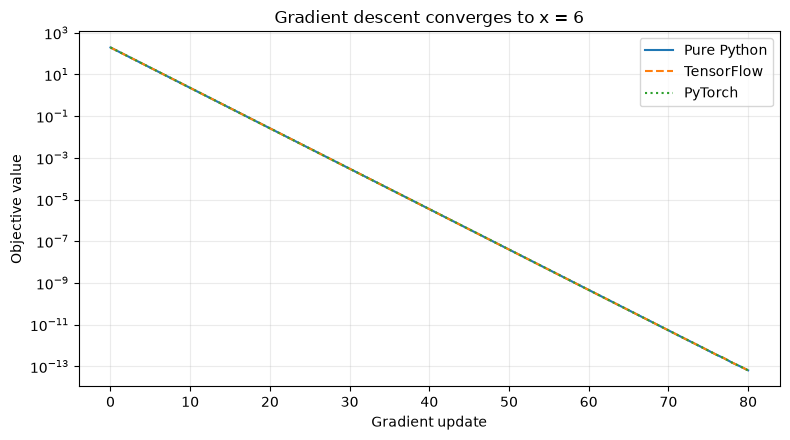

In [7]:
results = {
    "Pure Python": (python_value, objective(python_value)),
    "TensorFlow": (tensorflow_value, objective(tensorflow_value)),
    "PyTorch": (pytorch_value, objective(pytorch_value)),
}

for name, (value, loss) in results.items():
    print(f"{name:>11} | x = {value:.12f} | objective = {loss:.3e}")
    assert abs(value - 6.0) < 1e-6
    assert abs(loss) < 1e-10

assert max(abs(python_history[i] - tensorflow_history[i]) for i in range(steps + 1)) < 1e-10
assert max(abs(python_history[i] - pytorch_history[i]) for i in range(steps + 1)) < 1e-10

plt.figure(figsize=(8, 4.5))
plt.semilogy(python_history, label="Pure Python")
plt.semilogy(tensorflow_history, linestyle="--", label="TensorFlow")
plt.semilogy(pytorch_history, linestyle=":", label="PyTorch")
plt.xlabel("Gradient update")
plt.ylabel("Objective value")
plt.title("Gradient descent converges to x = 6")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## Observations

All three implementations follow the same optimization path and converge to the analytical minimum within the asserted tolerance. Pure Python requires the derivative to be derived and coded manually. TensorFlow and PyTorch instead obtain it from the recorded computation, which is the important advantage when a model contains many layers and parameters.

The NVIDIA GPU is visible to the operating system, but these CPU framework builds do not expose it. CPU execution is also the sensible choice here: one scalar and 80 updates cannot offset accelerator setup and transfer overhead. Later neural-network tasks can benefit from a CUDA-enabled PyTorch build when their matrix workloads are large enough.